# DataSynthesizer — feature QC visualizations

Eyeball one clip's saved training features: the **target mel**, the two aligned
**prior mels** (quantized + pitch-bend), a **delta mel** of each prior vs. the
target (`prior − target`, diverging colormap centered at 0), and the **onset mask**.
If the alignment is right, the onset-mask spikes line up with the note attacks in
the target mel, the prior mels' harmonics track the target's, and the delta mels
stay close to 0 where the prior matches.

To see detail, only the **first 5 seconds** of the clip are plotted (tune via
`ZOOM_S`).

Run from the **project root** so the `DataSynthesizer` package imports resolve
(`jupyter lab` launched there, or set the kernel CWD accordingly).

In [12]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

from common.config import SR
from DataSynthesizer.config import HOP

# Mels are precomputed and saved by build_dataset (BigVGAN mel via
# common.vocoder.mel_spectrogram), so this notebook just loads the .npy artifacts.

In [13]:
# --- pick a clip & load its saved features -------------------------------
base = "Kayser_Op20-01_AlexandrosIakovou_O105paQOHCE-0004-0064"

target_mel = np.load(f"data/target_mel/{base}.npy")
prior_quant = np.load(f"data/prior_mel_quant/{base}.npy")
prior_bend = np.load(f"data/prior_mel_bend/{base}.npy")
onset = np.load(f"data/prior_onset/{base}.npy")

T = target_mel.shape[-1]
t = librosa.frames_to_time(np.arange(T), sr=SR, hop_length=HOP)
assert prior_quant.shape == prior_bend.shape == target_mel.shape and onset.shape == (T,)
print(f"{base}\nmels {target_mel.shape}  onset {onset.shape}  ({t[-1]:.1f}s, {T} frames)")

Kayser_Op20-01_AlexandrosIakovou_O105paQOHCE-0004-0064
mels (128, 5161)  onset (5161,)  (59.9s, 5161 frames)


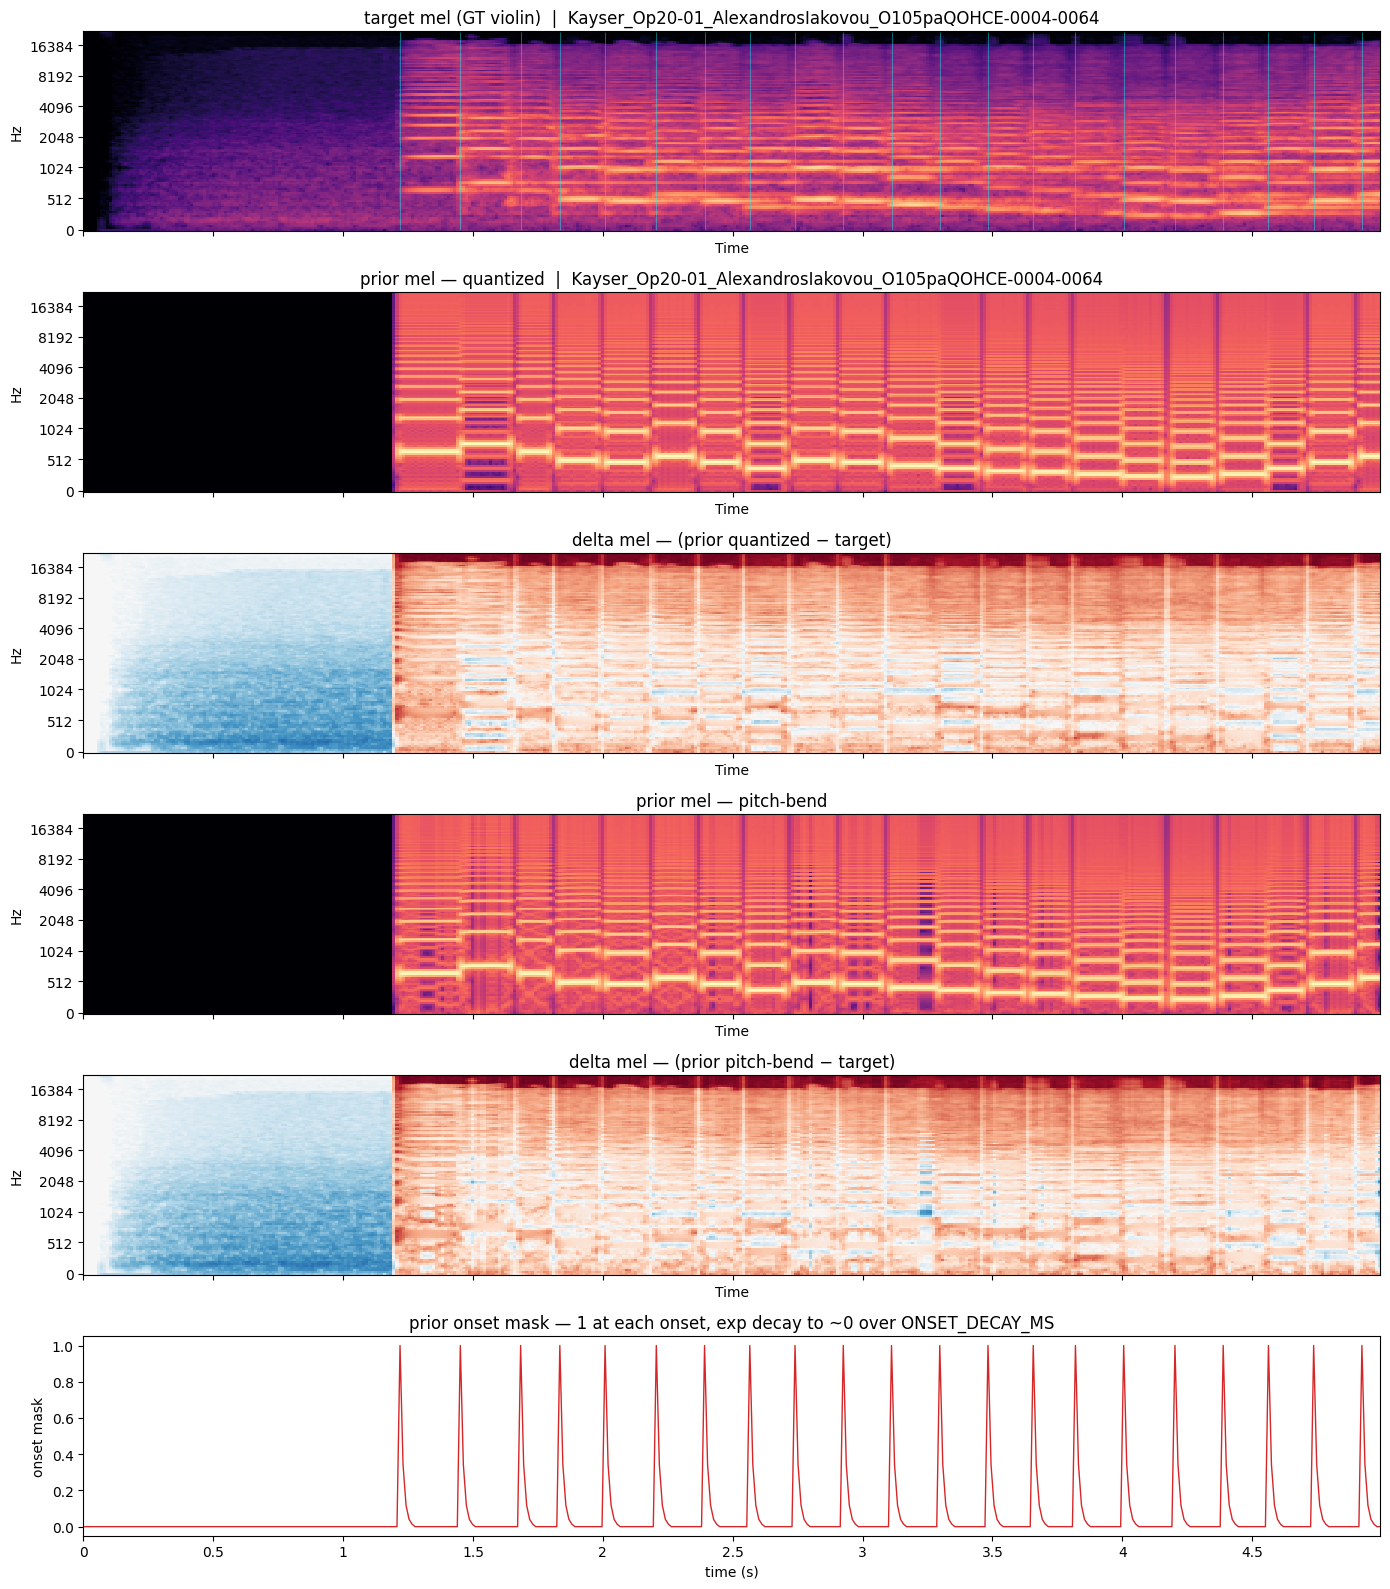

In [14]:
# --- target / prior mels (+ delta vs target) + onset mask ----------------
# zoom into the first 5 s so the harmonics/alignment are legible
ZOOM_S = 5.0
n5 = min(int(librosa.time_to_frames(ZOOM_S, sr=SR, hop_length=HOP)) + 1, T)
tz = t[:n5]
tgt_z, quant_z, bend_z = target_mel[:, :n5], prior_quant[:, :n5], prior_bend[:, :n5]
onset_z = onset[:n5]

# delta mels: prior - target (diverging, symmetric color scale around 0)
d_quant = quant_z - tgt_z
d_bend = bend_z - tgt_z
dmax = float(np.abs(np.concatenate([d_quant, d_bend])).max()) or 1.0

# shared sequential scale for the three absolute mels, so silence reads as the
# same dark floor everywhere (otherwise specshow auto-picks a diverging map for
# the priors and renders their floor blue instead of black)
MEL_CMAP = "magma"
mstack = np.concatenate([tgt_z, quant_z, bend_z])
mvmin, mvmax = float(mstack.min()), float(mstack.max())
mel_kw = dict(sr=SR, hop_length=HOP, x_axis="time", y_axis="mel",
              cmap=MEL_CMAP, vmin=mvmin, vmax=mvmax)

fig, ax = plt.subplots(6, 1, figsize=(14, 16), sharex=True)

# row 0-1: target + quantized prior + their delta
for a, mel, title in [
    (ax[0], tgt_z, "target mel (GT violin)"),
    (ax[1], quant_z, "prior mel — quantized"),
]:
    librosa.display.specshow(mel, ax=a, **mel_kw)
    a.set(title=f"{title}  |  {base}")

librosa.display.specshow(d_quant, sr=SR, hop_length=HOP, x_axis="time",
                         y_axis="mel", ax=ax[2], cmap="RdBu_r",
                         vmin=-dmax, vmax=dmax)
ax[2].set(title="delta mel — (prior quantized − target)")

# row 3-4: pitch-bend prior + its delta
librosa.display.specshow(bend_z, ax=ax[3], **mel_kw)
ax[3].set(title="prior mel — pitch-bend")
librosa.display.specshow(d_bend, sr=SR, hop_length=HOP, x_axis="time",
                         y_axis="mel", ax=ax[4], cmap="RdBu_r",
                         vmin=-dmax, vmax=dmax)
ax[4].set(title="delta mel — (prior pitch-bend − target)")

# mark onset-mask spikes (value == 1) on the target mel to check alignment
onset_frames = np.where(onset_z >= 0.999)[0]
ax[0].vlines(tz[onset_frames], 0, SR / 2, color="cyan", lw=0.5, alpha=0.6)

ax[5].plot(tz, onset_z, color="C3", lw=1.0)
ax[5].set(xlabel="time (s)", ylabel="onset mask", ylim=(-0.05, 1.05),
          title="prior onset mask — 1 at each onset, exp decay to ~0 over ONSET_DECAY_MS")

ax[5].set_xlim(0, tz[-1])
fig.tight_layout()
plt.show()